If you want an deployed version of the notebook, find it here:
https://rashdul.github.io/HW4/

# Problem Set 4: Tree Search in Games

<div class="alert alert-warning" markdown="1">

**Academic Integrity Note**: This assignment is designed to help you understand tree search algorithm fundamentals. While you may seek guidance and clarification, please ensure you can implement every solution yourself. This knowledge will be essential for your upcoming examinations.

</div>

<div class="alert alert-success" markdown="1">

**Submission Format**: Convert the final jupyter notebook to a single PDF file. For conceptual and mathematical questions, use Markdown.

It's recommended to first convert jupyter notebook to HTML, then print HTML to PDF in your browser.

```sh
pip install nbconvert==5.6.1
jupyter nbconvert --to html "$1"
```

</div>


## Part 1: Basic Tree Search Questions

For all three questions in this part, it is recommended to generate an image by modifying the provided Mermaid source code. However, you can always choose any other formats you prefer.


### Q1.1 (3 pts) Minimax

Given the game tree below, where the first player aims to maximize the utility value and the second player aims to minimize it.

Please compute the values of all `MAX` and `MIN` nodes.

> Hint: based on this [Mermaid source code](https://www.mermaidchart.com/play#pako:eNqNkE9PhDAQxb9Kw140GQzthsifxAQoEA968mCy7KFbQIgIBNa4xvjdpZRttujB6Wl-ee_NTL8M3uWF4RkvA-sr9ESzFk0VXO0eguf99dIh07xD4cTuH3UWKSZpOFOquSWLNRbNLPmDpYpJSmUi3mUGyYy9BskEtwrGco5Q2msolK6CiZwulNYaCiVWMJU7CeXtGhI1SGLesHGkRYne2AmVddN4m7LknB9gPA7dayFaa6qlNT_q_Fh5uD_5a3_dLn7ORYLyWxZj__A3BSvPC1jiqQDXdXW3dWP_9vfDe1vk6gRRKuEw1zkkZ2PFhoF9eshGW-Bd0w3exnEcX_sUFACFGBJIxd9cjkMhROJejVEMlECMISaQYEgIpBhSMt_lG98_TurCDA), you can simply change all `MAX/MIN` labels to `MAX/MIN=value` without any other modifications.

![minimax](./img/mermaid/minimax.png)

<span style="color: red;"><strong><i>YOUR ANSWER HERE</i></strong></span>


![minimax](./img/mermaid/part1.2.png)

### Q1.2 (3 pts) Alpha-Beta

Consider the same game tree as in Q1.1.

Please indicate which branches can be pruned, assuming the nodes are evaluated from left to right.

> Hint: based on the same [Mermaid source code](https://www.mermaidchart.com/play#pako:eNqNkE9PhDAQxb9Kw140GQzthsifxAQoEA968mCy7KFbQIgIBNa4xvjdpZRttujB6Wl-ee_NTL8M3uWF4RkvA-sr9ESzFk0VXO0eguf99dIh07xD4cTuH3UWKSZpOFOquSWLNRbNLPmDpYpJSmUi3mUGyYy9BskEtwrGco5Q2msolK6CiZwulNYaCiVWMJU7CeXtGhI1SGLesHGkRYne2AmVddN4m7LknB9gPA7dayFaa6qlNT_q_Fh5uD_5a3_dLn7ORYLyWxZj__A3BSvPC1jiqQDXdXW3dWP_9vfDe1vk6gRRKuEw1zkkZ2PFhoF9eshGW-Bd0w3exnEcX_sUFACFGBJIxd9cjkMhROJejVEMlECMISaQYEgIpBhSMt_lG98_TurCDA) in Q1.1, you can simply use `pruned` class to indicate the pruned branches at Line 28 without any other modifications.

<span style="color: red;"><strong><i>YOUR ANSWER HERE</i></strong></span>


![minimax](./img/mermaid/pruned.png)

### Q1.3 (3 pts) Expectimax

Let’s modify the game tree from Q1.1 to construct a new one for expectimax.

Please compute the values of all `MAX` and `CHANCE` nodes.

> Hint: based on this [Mermaid source code](https://www.mermaidchart.com/play#pako:eNqFj1FLwzAUhf9KiC8TbjXJGJIKQtsk9UWffBDaPdSsscO6jXXgwPrfbdouNAXx5ul-59xzb76x3m9KHOL3Y3Go0IvId6iraJE9Ra_r67FDQfCA4kWWPEbPifRxMsWDEFuhZbfLFgkvaBCoFaQnJKPAWqT-ElInDJLo1wua5ZjleO1B1sGlg7KH0jpXc2id3EHVQ2WdZA6tkzqY9jC1zrs5ZG7RgHVdNI0oDfoszshs6zq8MkZr_QbN6bj_KG1Luhrb4Gu7OVUhPZzvZ_O6Kna6HCO0NsQYF0EI51r_G1GXhbncQOxzAZxzf5rcrPr5SQKKQIAEBan9yzQbxZCM93lYUBAMJAXJQFFQDFIKKevv6Iz45xd2_7Bw), you can simply change all `MAX/CHANCE` labels to `MAX/CHANCE=value` without any other modifications.

![expectimax](./img/mermaid/expectimax.png)

<span style="color: red;"><strong><i>YOUR ANSWER HERE</i></strong></span>


![minimax](./img/mermaid/part1.3.png)

## Part 2: Monte Carlo Tree Search Implementation

<div class="alert alert-warning" markdown="1">

**Important**: Please use only the libraries imported in the next cell. Do not import any additional libraries beyond what is already provided.

</div>


In [1]:
!pip install --force-reinstall matplotlib==3.10.6 pygame==2.6.1 requests==2.32.5 tqdm==4.67.1

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.6-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached pygame-2.6.1-cp313-cp313-win_amd64.whl.metadata (13 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp313-cp313-win_amd64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached numpy-2.3.4-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pillow-12.0.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
 

In [2]:
import math
import random

from IPython.display import clear_output
from tqdm import trange

from utils import BaseAgent, HumanAgent, OnlineAgent, RandomAgent, State

random.seed(42)

pygame 2.6.1 (SDL 2.28.4, Python 3.13.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


We will implement Monte Carlo Tree Search to play a classic two-player zero-sum board game: Connect 4.

To understand the rules, you can check out the [Wikipedia description](https://en.wikipedia.org/wiki/Connect_Four), this [Youtube video](https://youtu.be/ylZBRUJi3UQ), or [play it here](https://connect4.gamesolver.org/).

Note that the red piece (1) moves first, followed by the black piece (2), and the two sides alternate turns until the game ends.

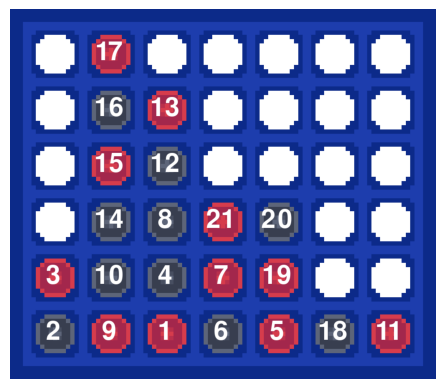

=== State ===
Board:          
[[0 1 0 0 0 0 0]
 [0 2 1 0 0 0 0]
 [0 1 2 0 0 0 0]
 [0 2 2 1 2 0 0]
 [1 2 2 1 1 0 0]
 [2 1 1 2 1 2 1]]
Current Steps:  21
Self Piece:     1 (red)
IsTerminal:     False
Result:         None

=== Actions ===
Valid Actions:  [0, 2, 3, 4, 5, 6]
Next Action:    Column 3


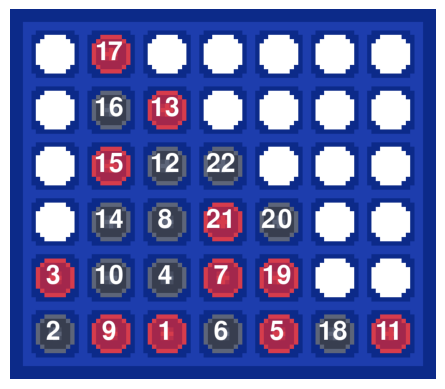

=== New State ===
IsTerminal:     True
Result:         {2: 1, 1: -1}


In [3]:
state = State(
    [
        [0, 17, 0, 0, 0, 0, 0],
        [0, 16, 13, 0, 0, 0, 0],
        [0, 15, 12, 0, 0, 0, 0],
        [0, 14, 8, 21, 20, 0, 0],
        [3, 10, 4, 7, 19, 0, 0],
        [2, 9, 1, 6, 5, 18, 11],
    ]
)


state.render()
print(f"=== State ===")
print(f"Board:          \n{state.board}")
print(f"Current Steps:  {state.current_steps}")
print(f"Self Piece:     {state.piece} ({'red' if state.piece == 1 else 'black'})")
print(f"IsTerminal:     {state.is_terminal}")
print(f"Result:         {state.result}")
print()

print(f"=== Actions ===")
print(f"Valid Actions:  {state.valid_actions}")
action = 3
print(f"Next Action:    Column {action}")

state = state.transition(action)
state.render()

print(f"=== New State ===")
print(f"IsTerminal:     {state.is_terminal}")
print(f"Result:         {state.result}")

### Q2.1 (2 pts) MCTS Node

First, let's define the `MCTSNode` class. Implement `uct_score()`, and use it in `select_action()`.

In [32]:
class MCTSNode:
    def __init__(self, state, parent=None, action=None):
        self.state = state
        self.parent = parent
        self.action = action
        self.children = []
        self.visits = 0  # N(s, a), number of times the node has been visited
        self.value = 0  # Q(s, a), total value of the node

    def uct_score(self, exploration_rate):
        """
        Calculate the UCT score for the current node
        """
        exploitation = self.value / self.visits if self.visits != 0 else 0
        exploration = exploration_rate * math.sqrt(math.log(self.parent.visits) / self.visits) if self.visits != 0 else float('inf')
        uct = exploitation + exploration
        return uct

    def select_action(self, exploration_rate):
        """
        Select and return the child with the highest UCT score.
        """
        if not self.children:
            return None
        return max(self.children, key=lambda child: child.uct_score(exploration_rate))

### Q2.2 (2 pts) MCTS Agent

Next, let's define the `MCTSAgent` class and implement it in a top-down manner.

Specifically, we will first implement the `policy()` function, assuming that the 4 helper functions -- `select()`, `expand()`, `simulate()`, and `backprop()` -- have already been implemented.

After all simulations, we will select the child with the **highest visits** (instead of the highest UCT score) as the best action.

In [33]:
class MCTSAgent(BaseAgent):
    def __init__(self, num_simulations, default_policy, exploration_rate):
        self.default_policy = default_policy
        self.num_simulations = num_simulations
        self.exploration_rate = exploration_rate

    def policy(self, state):
        # TODO: YOUR CODE HERE
        root = MCTSNode(state=state)

        for k in range(self.num_simulations):
            # TODO: YOUR CODE HERE
            node = root
            # Selection
            node = self.select(node)
            # Expansion
            if not node.state.is_terminal:
                self.expand(node)
                node = random.choice(node.children)
                
            # Simulation
            result = self.simulate(node.state)
            # Backpropagation
            self.backprop(node, result)

        best_child = max(root.children, key=lambda child: child.visits)

        return best_child.action

In the next 4 questions, you will implement the 4 helper functions respectively.

### Q2.3 (2 pts) Selection

Select the best child from node until a leaf node is reached.

In [34]:
def select(self, node):
    # node = MCTSNode(state=node.state)
    while node.children:
        node = node.select_action(self.exploration_rate)
    return node

### Q2.4 (2 pts) Expansion

Expand the node by creating all possible child nodes.

> API reference:
>
> - `node.state.valid_actions: list[int]`: get all valid actions
> - `node.state.transition(action): State`: get a new state from an action


In [35]:
def expand(self, node):
    # TODO: YOUR CODE HERE
    node_actions = node.state.valid_actions
    for action in node_actions:
        new_state = node.state.transition(action)
        child_node = MCTSNode(state=new_state, parent=node, action=action)
        node.children.append(child_node)

### Q2.5 (2 pts) Simulation

Simulate the game until the end.

> API reference:
>
> - `state.is_terminal: bool`: check if the game is over
> - `self.default_policy.policy(state): int`: simulate the opponent's action.
> - `state.result: dict[int, int]`: get the result of the game (keys are pieces, values are utilities)

In [36]:
def simulate(self, state):
    # TODO: YOUR CODE HERE
    current_state = state
    while not current_state.is_terminal:
        action = self.default_policy.policy(current_state)
        current_state = current_state.transition(action)
    return current_state.result

### Q2.6 (2 pts) Backpropagation

Backpropagate the result up to the root node.

> API reference:
>
> - `node.state.piece: int`: the piece of the node

In [37]:
def backprop(self, node, result):
    # TODO: YOUR CODE HERE
    while node is not None:
        node.value += result[node.state.piece]
        node.visits += 1
        node = node.parent

Finally, we attach these standalone functions to the `MCTSAgent` class using a Python feature for dynamic class modification, known as *monkey patching*.

In [38]:
MCTSAgent.select = select
MCTSAgent.expand = expand
MCTSAgent.simulate = simulate
MCTSAgent.backprop = backprop

### Q2.7 (1 pt) Evaluation: Self-Play

Run 10 games with the MCTS agent playing against itself under the same configuration using the code below.
Is the win rate close to 50% or not? Why?

> Expected runtime: ~10 × 30 s ≈ 5 min.

<span style="color: red;"><strong><i>YOUR ANSWER HERE</i></strong></span>


In [39]:
def one_game(agents, visualize):
    state = State()

    if visualize:
        state.render()

    while not state.is_terminal:
        action = agents[state.opponent_piece].policy(state)
        state = state.transition(action)

        if visualize:
            clear_output(wait=True)
            state.render()

    return state.result


def multiple_games(agents, total_games=10):
    cnt = dict(win=0, draw=0, lose=0)

    for i in trange(total_games):
        reward = one_game(agents, visualize=(i == 0))
        if reward[1] == 1:
            cnt["win"] += 1
        elif reward[1] == -1:
            cnt["lose"] += 1
        else:
            cnt["draw"] += 1

        for k, v in cnt.items():
            print(f"{k}: {v / sum(cnt.values()):.1%}", end="\t")
        print()

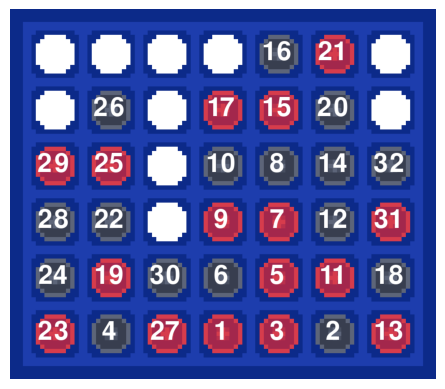

 10%|█         | 1/10 [00:22<03:23, 22.60s/it]

win: 0.0%	draw: 0.0%	lose: 100.0%	


 20%|██        | 2/10 [00:37<02:22, 17.79s/it]

win: 0.0%	draw: 0.0%	lose: 100.0%	


 30%|███       | 3/10 [00:44<01:30, 12.94s/it]

...

win: 25.0%	draw: 0.0%	lose: 75.0%	


 90%|█████████ | 9/10 [02:41<00:20, 20.05s/it]

win: 33.3%	draw: 0.0%	lose: 66.7%	


100%|██████████| 10/10 [02:56<00:00, 17.68s/it]

win: 30.0%	draw: 10.0%	lose: 60.0%	


In [40]:
mcts = MCTSAgent(
    default_policy=RandomAgent(),
    num_simulations=200,
    exploration_rate=math.sqrt(2),
)
multiple_games(agents={1: mcts, 2: mcts}, total_games=10)

### Q2.8 (1 pt) Evaluation: Worthy Opponent

If the win rate is not close to 50%, how would you only adjust `num_simulations` to make a worthy opponent?

To avoid expensive parameter tuning, choose a more reasonable number in (150, 250) and run the code below with the parameter `worthy_num_simulations`.

<span style="color: red;"><strong><i>YOUR ANSWER HERE</i></strong></span>


number of simmulations controls the depth of MCTS tree, if a player wins more against the other, we would increase the number until we get equal rates.

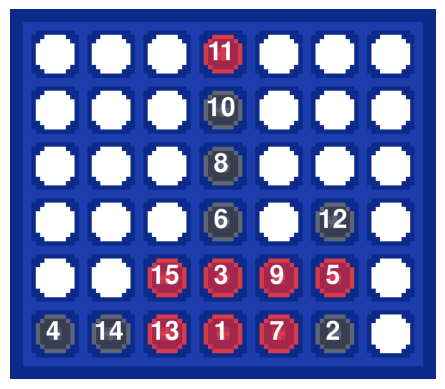

 10%|█         | 1/10 [00:10<01:37, 10.88s/it]

win: 100.0%	draw: 0.0%	lose: 0.0%	


 20%|██        | 2/10 [00:26<01:48, 13.54s/it]

win: 100.0%	draw: 0.0%	lose: 0.0%	


 30%|███       | 3/10 [00:36<01:25, 12.20s/it]

...

win: 75.0%	draw: 0.0%	lose: 25.0%	


 90%|█████████ | 9/10 [02:01<00:13, 13.05s/it]

win: 77.8%	draw: 0.0%	lose: 22.2%	


100%|██████████| 10/10 [02:09<00:00, 12.94s/it]

win: 80.0%	draw: 0.0%	lose: 20.0%	


In [41]:
worthy_num_simulations = 150
assert worthy_num_simulations in (150, 250)
worthy_opponent = MCTSAgent(
    default_policy=RandomAgent(),
    num_simulations=worthy_num_simulations,
    exploration_rate=math.sqrt(2),
)
multiple_games(agents={1: mcts, 2: worthy_opponent}, total_games=10)

### Q2.9 (1 pt) Evaluation: Stronger Opponent

Let's compete with a stronger agent!
By running the code below, your `MCTSAgent` (you take the red piece and move first) will compete against a strong online agent from `https://ludolab.net/play/four-in-a-line/computer`.
Adjust the `num_simulations` parameter in the code below to make your agent stronger. 

<div class="alert alert-success" markdown="1">

You will receive full points for this question if your agent **wins more than 80%** out of 10 games.

For quick tests, the expected win rate with 100 simulations is above 50%.

</div>


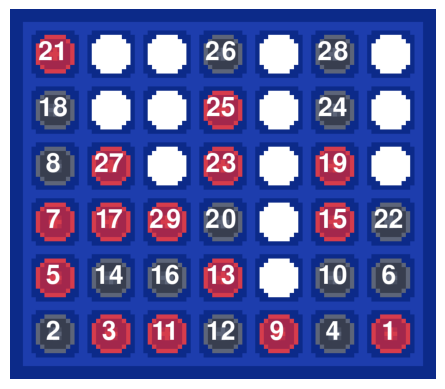

 10%|█         | 1/10 [00:32<04:56, 32.92s/it]

win: 100.0%	draw: 0.0%	lose: 0.0%	


 20%|██        | 2/10 [00:53<03:26, 25.80s/it]

win: 100.0%	draw: 0.0%	lose: 0.0%	


 30%|███       | 3/10 [01:10<02:32, 21.82s/it]

...

win: 87.5%	draw: 0.0%	lose: 12.5%	


 90%|█████████ | 9/10 [03:43<00:23, 23.82s/it]

win: 88.9%	draw: 0.0%	lose: 11.1%	


100%|██████████| 10/10 [04:01<00:00, 24.19s/it]

win: 90.0%	draw: 0.0%	lose: 10.0%	


In [42]:
stronger_mcts = MCTSAgent(
    default_policy=RandomAgent(),
    num_simulations=100,
    exploration_rate=math.sqrt(2),
)
solver = OnlineAgent(level=1)
multiple_games(agents={1: stronger_mcts, 2: solver}, total_games=10)

## (Optional) Enjoy the game!

Play the game yourself! Can you beat the MCTS agent you created?


  0%|          | 0/1 [00:00<?, ?it/s]

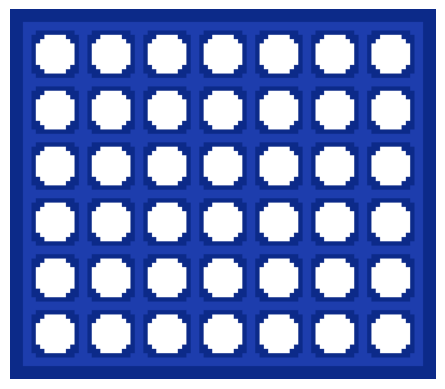

In [ ]:
human = HumanAgent()
multiple_games(agents={1: human, 2: mcts}, total_games=1)